# Project Overview

The goal of this project is to build an end-to-end content-based Recommender System (RS) for video games using a dataset of over 120,000 PC video games available on Steam.

**[data_business.ipynb](./data_business.ipynb)**: Walks through the entire data science pipeline: from raw metadata cleaning and exploratory data analysis to answering key business insights.

**[recommender.ipynb](./recommender.ipynb)**: Covers the design and execution of the RS architecture, followed by both qualitative evaluation (relevance and serendipity) and quantitative evaluation (using Recall, ILD and novelty.)

**[app.py](/app.py)**: Deploys the production ready recommendation algorithm as a web application to Streamlit. 

**Interactive Web App**: You can test the live recommender here: [Steam Games Recommender](https://shujoshi-steam-recommender.streamlit.app/).

**P.S.**: This notebook continues where [data_business.ipynb](./data_business.ipynb) left off. Please see that notebook first if you haven't already!

# Table of Contents

- [$\Psi$. Recommender Architecture Overview](#$\Psi$.-Recommender-Architecture-Overview)
- [i. Filtering & Weighting](#i.-Filtering-&-Weighting)
    - [1. Dataset Filtering](#i.1.-Dataset-Filtering)
    - [2. Weighting the Features](#i.2.-Weighting-the-Features)
- [ii. Recommender Architecture](#ii.-Recommender-Architecture)
    - [1. Building the Matrices](#ii.1.-Building-the-Matrices)
    - [2. Recommendation Algorithm](#ii.2.-Recommendation-Algorithm)
- [iii. Evaluating the Recommender System](#iii.-Evaluating-the-Recommender-System)
    - [1. Qualitative Evaluation](#iii.1.-Qualitative-Evaluation)
        - [x. Example 1](#iii.1.x.-Example-1)
        - [y. Example 2](#iii.1.y.-Example-2)
    - [2. Quantitative Evaluation](#iii.2.-Quantitative-Evaluation)
    - [3. Interpreting Evaluation Metrics](#iii.3.-Interpreting-Evaluation-Metrics) 
- [iv. Conclusions & Future Work](#iv.-Conclusions-&-Future-Work)

# $\Psi$. Recommender Architecture Overview

We choose the cosine similarity distance as our metric of how similar two games are. Given two games, let $A$ and $B$ represent the vectors that encode the game's gameplay and quality. The cosine distance between the two games is:

$$\cos(A, B) = \frac{A \cdot B}{\|A\| \|B\|},$$

where the numerator is the usual vector dot product and the denominator is the product of the magnitudes of the vectors. This formulation of similarity ensures that games sharing thematic feel and gameplay mechanics are deemed similar.

**High-level overview of the Recommender System**:

1. The user will input three games and the RS will output 10 similar games, 2 of which are free-to-play.
2. The features of the input games will be converted to a similarity matrix and its distance to all games in a subset of df_topten will be calculated using cosine similarity.
3. Games to be recommended will be ranked by cosine similarity (top games have the largest similarity score).
4. The top 8 paid games and the top 2 free-to-play games will be output as the recommendations.

We'll justify the choice of the ratio 8:2 for paid and free-to-play games below.  

Some salient features of the Recommender System:

* **Under the hood**: We essentially construct two recommender systems: one will recommend 8 paid games and the other, 2 free-to-play games. Constructing two recommender systems is necessary since the features used to recommend paid games are not the same as the ones used to recommend free games. 

* **Cold Start Mitigation**: If all three input games exist in our dataset but are missing Characteristics data, the recommender will print out a message along with a curated list of top games to recommend. 

* **Serendipity vs Redundancy**: The RS is constructed so that recommendations are not necessarily other titles in the franchise as the input. This ensures that titles from other franchises surface up and could act as serendipitous discoveries for the user. 

# i. Filtering & Weighting

We further prepare our already cleaned features to be injected into the recommender system: Characteristics, Bayesian votes, Estimated yearly revenue and Estimated owners. We first filter df_clean to define the dataset from which we generate recommendations and then we give weights to our features. 

Recall: 

* **Characteristics**: Contains the joint information from Genres, Categories and Tags. This feature captures a game's themes, atmosphere and gameplay mechanics.

* **Bayesian votes**: Gives a relative ranking of games by percentage of positive votes. A game with more total votes is ranked higher if it has the same percentage of total votes as another game with fewer total votes. 

* **Estimated yearly revenue**: A crude measure of financial performance of paid games.

* **Estimated owners**: A crude estimate of the performance of a free-to-play game. 

* **df_clean**: The cleaned dataset obtained as culmination of the data cleaning done in [data_business.ipynb](./data_business.ipynb).



## i.1. Dataset Filtering

Not every game is worth recommending! We now slice off our dataset to create a dataframe that contains the games we actually wish to recommend. So we must rank games using an objective metric. Thankfully, we've already done all the hard work at creating such a metric. 

Our main indicator of a game's quality is Bayesian votes. It is implausible that we recommend games with no votes or in general, a low Bayesian votes score. At the same time, we wish to use a small subset of the dataframe to recommend games. We choose to recommend games from the top 10% of games ordered by Bayesian votes. This will give us a healthy number of games (~11k) to recommend from while still being a small and a "premium" subset of the dataset, aka., cr&egrave;me de la cr&egrave;me. 

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import re
import random
import streamlit as st

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', None) # Display any number of columns.

In [132]:
df_clean = pd.read_csv('C:/Python/Data Science Projects/Steam Games/data/games_clean.csv')

In [133]:
df_clean['Bayesian votes'].describe()

count    109087.000000
mean          0.645167
std           0.156393
min           0.105009
25%           0.512990
50%           0.621215
75%           0.773716
max           0.995773
Name: Bayesian votes, dtype: float64

In [134]:
int(len(df_clean) * 0.10)

10908

In [135]:
df_clean.iloc[11445, 0] 

'What have you done, Father?'

The game Paleo Pines is at the edge of our 10% quality cutoff. Heading over to its [Steam webpage](https://store.steampowered.com/app/1202200/Paleo_Pines/), we see that we most certainly want to recommend games better than this one. This tells us that our cutoff is chosen appropriately. 

In [136]:
# Define a new dataframe that consists of the top 10% games by Bayesian votes.

threshold = df_clean['Bayesian votes'].quantile(0.90)

df_topten = df_clean[df_clean['Bayesian votes'] >= threshold].copy()

In [137]:
len(df_topten)

10909

We now break up df_topten into two dataframes, one to recommend paid games from and another to recommend free-to-play games from. 

In [138]:
# Calculate the percentage of free-to-play games in the df_topten dataframe.

len(df_topten.loc[df_topten['Price'] == 0]) / len(df_topten) * 100

9.982583188193235

**Why 8:2?**: Since about 10% of games in df_topten are free-to-play, we could recommend 1 free-to-play games and 9 paid games. However, to give the user the option to explore free games similar to the ones they like, we recommend 2 free-to-play games instead of 1. In this way, they might consider paying for paid recommendations once they trust the recommender system to give them meaningful recommendations after having tried the free ones. 

We crerate two dataframes from df_topten: df_paid_topten and df_free_topten. 

In [139]:
# Dataframe to recommend paid games.
df_paid_topten = df_topten[df_topten['Price'] != 0].copy()

# Dataframe to recommend free games.
df_free_topten = df_topten[df_topten['Price'] == 0].copy()

# Save these as csv so that we can use them when we deploy our app on Streamlit. 
df_paid_topten.to_csv('C:/Python/Data Science Projects/Steam Games/data/df_paid_topten.csv', index = False)
df_free_topten.to_csv('C:/Python/Data Science Projects/Steam Games/data/df_free_topten.csv', index = False)

Let's look at the heads of these new datasets.

In [140]:
df_paid_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
0,Kabuto Park,2025-05-28,0.555777,3.99,1,https://shared.akamai.steamstatic.com/store_it...,153,"Single-player,Steam Achievements,Steam Trading...","Casual,Indie,RPG,Simulation,Strategy","Casual,Creature Collector,Nature,Cozy,Cute,Car...",0.94,https://store.steampowered.com/app/3376990/,0.549027,0.995773,casual playablewithouttimedinput deckbuilding ...
1,Aokana - Four Rhythms Across the Blue - EXTRA2,2022-12-16,0.555777,17.49,1,https://shared.akamai.steamstatic.com/store_it...,320,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual,Sports","Visual Novel,Story Rich,Sports,Cute,Romance,An...",3.39,https://store.steampowered.com/app/2206340/,0.558023,0.994178,casual romance funny emotional nudity storyric...
3,A Castle Full of Cats,2022-11-09,0.633077,2.39,1,https://shared.akamai.steamstatic.com/store_it...,131,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Wholesome,Point & Click,Coz...",3.49,https://store.steampowered.com/app/2070550/,0.532016,0.993424,casual vampire relaxing hiddenobject puzzle ad...
4,A Tower Full of Cats,2024-05-20,0.555777,4.19,1,https://shared.akamai.steamstatic.com/store_it...,293,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Puzzle,Point & Click,Creatu...",1.96,https://store.steampowered.com/app/2179170/,0.517405,0.993214,casual timetravel relaxing hiddenobject storyr...
5,Beastieball,2024-11-12,0.555777,21.24,1,https://shared.akamai.steamstatic.com/store_it...,260,"Single-player,Multi-player,PvP,Online PvP,Stea...","Adventure,Indie,RPG,Sports,Early Access","Early Access,Creature Collector,Sports,Turn-Ba...",1.48,https://store.steampowered.com/app/1864950/,0.605188,0.992843,esports playablewithouttimedinput controller t...


In [141]:
df_free_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
2,The WereCleaner,2024-05-07,0.678083,0.0,1,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy,Free To Play","Stealth,Casual,Cartoony,Dark Humor,Strategy,Cu...",2.00,https://store.steampowered.com/app/2795000/,0.0,0.994034,casual controller tactical werewolves actionad...
17,HoloCure - Save the Fans!,2023-08-16,0.755384,0.0,0,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Casual,Indie","Pixel Graphics,Bullet Hell,Anime,Action Roguel...",2.72,https://store.steampowered.com/app/2420510/,0.0,0.990356,casual fantasy pixelgraphics actionroguelike f...
19,Buy a Croquette!,2024-04-27,0.633077,0.0,2,https://shared.akamai.steamstatic.com/store_it...,230,"Single-player,Steam Achievements,Full controll...","Adventure,Casual,Indie,RPG,Strategy,Free To Play","RPGMaker,Mystery,Sci-fi,Puzzle,Psychological H...",2.02,https://store.steampowered.com/app/2167960/,0.0,0.989689,casual controller pixelgraphics funny femalepr...
33,Our Life: Beginnings & Always,2020-11-16,0.718566,0.0,9,https://shared.akamai.steamstatic.com/store_it...,461,"Single-player,Steam Achievements","Casual,Indie,Free To Play","Visual Novel,Romance,LGBTQ+,Character Customiz...",5.47,https://store.steampowered.com/app/1129190/,0.0,0.988008,casual romance otome funny relaxing characterc...
43,Word Game: Episode 0,2021-01-14,0.633077,0.0,0,https://shared.akamai.steamstatic.com/store_it...,36,Single-player,"Adventure,Indie,RPG,Strategy","Minimalist,Indie,Pixel Graphics,Puzzle,Free to...",5.31,https://store.steampowered.com/app/1507970/,0.0,0.986929,pixelgraphics jrpg storyrich puzzle adventure ...


## i.2. Weighting the Features

The RS we are constructing is best thought as two recommender systems.

**Recommender 1**: Recommending Paid Games: This recommender will use the features Characteristics, Bayesian votes and Estimated yearly revenue and recommend 8 games from the dataframe df_paid_topten.

**Recommender 2**: Recommending Free Games: This recommender will use the features Characteristics, Bayesian votes and Estimated owners and recommend 2 games from the dataframe df_free_topten.

Our RS will simply output the results of the above two recommender systems. 

We need to decide how strongly the selected features influence our RS. For this purpose, we need to check how correlated they are. The only pairs we need to check are how Bayesian votes is correlated with Estimated yearly revenue (for Recommender 1) and how Bayesian votes is correlated with Estimated with Estimated owners (for Recommender 2). 

In [142]:
pearson_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='pearson')
spearman_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: 0.2153
Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: 0.1993


In [143]:
pearson_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='pearson')
spearman_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated owners is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated owners is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated owners is: 0.1870
Spearman Correlation (rank) between Bayesian votes and Estimated owners is: 0.2157


**Verdict**: This is incredibly surprising. One would expect highly rated games to also have generated some of the highest revenue and vice versa, but that is not the case. We conclude that these features are independent and therefore, we weigh them accordingly.

**Weights**: We'll weigh Characteristics 50%, Bayesian votes 40% and Estimated yearly revenue 10% (Estimated owners 10% for Recommender 2). The reasoning: we want to find games that are similar mainly by how they "feel" when played. Characteristics captures this exact DNA of the game. Next, we weigh Bayesian votes significantly higher than Estimated yearly revenue (and Estimated owners) for two reasons. One, Bayesian votes is a relatively far more robust and objective metric of a game's quality, and second, recall that Estimated owners (and therefore, Estimated yearly revenue) is a very crude estimate of a game's (financial) performance. Therefore, Estimated yearly revenue / Estimated owners should get a say, but only a whisper. 

# ii. Recommender Architecture

We'll first construct the feature matrices. In doing so, we'll also apply the feature weights directly into the matrices. Then we will construct the recommendation algorithm.

## ii.1. Building the Matrices

In [144]:
# This function builds the matrices that the RS will accept onto which it can compute cosine similarity.

def build_matrices(df_clean, df_paid_topten, df_free_topten):
    char_vectorizer = CountVectorizer(token_pattern = r'(?u)\b\w+\b') 
    char_vectorizer.fit(df_topten['Characteristics'].fillna(''))

    # I. Matrix for paid games (Using 50/40/10 weights)

    # Transform (uses the master vocabulary)
    char_sparse_paid = char_vectorizer.transform(df_paid_topten['Characteristics'].fillna(''))
    char_weighted_paid = char_sparse_paid * np.sqrt(0.5)
    
    # Extract and weight votes & revenue.
    votes_weighted_paid = (df_paid_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1) # reshape(-1,1) converts a 1d matrix to 2d so that hstack works correctly.
    revenue_weighted_paid = (df_paid_topten['Estimated yearly revenue'].values * np.sqrt(0.1)).reshape(-1, 1)
    
    # Stack to create the paid master feature matrix.
    X_paid = hstack([char_weighted_paid, votes_weighted_paid, revenue_weighted_paid]).tocsr()
    
    
    # II. Matrix for free games (Using 50/40/10 weights)
    
    
    # Transform (uses the master vocabulary).
    char_sparse_free = char_vectorizer.transform(df_free_topten['Characteristics'].fillna(''))
    char_weighted_free = char_sparse_free * np.sqrt(0.5)
    
    # Extract and weight votes & owners.
    votes_weighted_free = (df_free_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1)
    owners_weighted_free = (df_free_topten['Estimated owners'].values * np.sqrt(0.1)).reshape(-1, 1)
    
    # Stack to create the free master feature matrix.
    X_free = hstack([char_weighted_free, votes_weighted_free, owners_weighted_free]).tocsr()

    return char_vectorizer, X_paid, X_free

In [145]:
# Initialize data to be fed into the recommender algorithm. 
char_vectorizer, X_paid, X_free = build_matrices(df_clean, df_paid_topten, df_free_topten)

## ii.2. Recommendation Algorithm

We're now ready to write out the actual recommendation algorithm.

In [146]:
# Recommender algorithm: Recommends 8 paid games and 2 free games based on a list of input games.

"""
    Function parameters:
    - input_titles: List of 3 strings (the user's input games)
    - df_paid_topten: Subset of cleaned & filtered dataset (df_topten) from which to recommend paid games 
    - X_paid: Weighted feature matrix for df_paid_topten
    - df_free_topten: Subset of cleaned & filtered dataset (df_topten) from which to recommend paid games
    - X_free: Weighted feature matrix for df_free_topten
    - df_master: Cleaned & filtered dataset to lookup input profiles, i.e., df_topten
    - char_vectorizer: The (count) vectorizer used on Characteristics
"""



def recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_master, char_vectorizer):
    
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    import pandas as pd
    from scipy.sparse import hstack

    # Standardize input titles for robust matching
    input_titles_clean = [title.strip().lower() for title in input_titles]
    
    # 1. Locate the input games in df_master
    matched_games = df_master[df_master['Name'].str.strip().str.lower().isin(input_titles_clean)]
    
    # Check if we have at least one valid game in df_master.
    
    if matched_games.empty:
        # Fallback 1: None of the input games exist on Steam at all
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by = 'Bayesian votes', ascending = False).head(8)
        fallback_free = df_free_topten.sort_values(by = 'Bayesian votes', ascending = False).head(2)
        return fallback_paid, fallback_free, message
    

# Check if all input games are missing Characteristics data in our dataset.

    
    # Clean up the strings to check for empty/NaN values
    has_characteristics = matched_games['Characteristics'].fillna('').str.strip() != ""
    
    if not has_characteristics.any():  # If ALL matched games have missing Characteristics
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by = 'Bayesian votes', ascending=False).head(8)
        fallback_free = df_free_topten.sort_values(by = 'Bayesian votes', ascending=False).head(2)
        return fallback_paid, fallback_free, message

    
    # Construct feature vectors for input games.
    
    # Filter matched games down to the ones that actually have characteristics.
    profile_games = matched_games[has_characteristics]
    
    # Project their characteristics into the vectorizer space and apply characteristics weight (50%)
    char_sparse_query = char_vectorizer.transform(profile_games['Characteristics'].fillna(''))
    char_weighted_query = char_sparse_query * np.sqrt(0.5)
    
    # Extract popularity metrics
    votes_query = profile_games['Bayesian votes'].values.reshape(-1, 1)
    revenue_query = profile_games['Estimated yearly revenue'].values.reshape(-1, 1)
    owners_query = profile_games['Estimated owners'].values.reshape(-1, 1)
    
    # Build the input games' vector for comparing with paid games
    votes_weighted_query_paid = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    revenue_weighted_query_paid = (revenue_query * np.sqrt(0.1)).reshape(-1, 1)
    
    # Stack the features for the inputs and take the mean to make a single 1D query vector
    query_matrix_paid = hstack([char_weighted_query, votes_weighted_query_paid, revenue_weighted_query_paid]).tocsr()
    query_vector_paid = np.mean(query_matrix_paid.toarray(), axis=0).reshape(1, -1)

    # Build the query vector for comparing with free games.
    votes_weighted_query_free = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    owners_weighted_query_free = (owners_query * np.sqrt(0.1)).reshape(-1, 1)
    
    query_matrix_free = hstack([char_weighted_query, votes_weighted_query_free, owners_weighted_query_free]).tocsr()
    query_vector_free = np.mean(query_matrix_free.toarray(), axis=0).reshape(1, -1)

# Compute cosine similarity and obtain recommendations.
    
    # Compute similarities and compare with the paid target matrix
    paid_similarities = cosine_similarity(query_vector_paid, X_paid).flatten()
    df_paid_results = df_paid_topten.copy()
    df_paid_results['similarity_score'] = paid_similarities
    
    # Filter out inputs
    df_paid_results = df_paid_results[~df_paid_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_paid = df_paid_results.sort_values(by = 'similarity_score', ascending = False).head(8)

    # Compute similarities and compare against the free target matrix.
    free_similarities = cosine_similarity(query_vector_free, X_free).flatten()
    df_free_results = df_free_topten.copy()
    df_free_results['similarity_score'] = free_similarities
    
    # Filter out inputs
    df_free_results = df_free_results[~df_free_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_free = df_free_results.sort_values(by = 'similarity_score', ascending = False).head(2)

    return top_paid, top_free, None

# iii. Evaluating the Recommender System

We first check the performance pf the RS by looking at explicit examples and seeing if they make sense. Later, we'll run some metrics to quantify the recommendation algorithm's performance.

## iii.1. Qualitative Evaluation

Let's take our recommender out for a spin! 

### iii.1.x. Example 1

We choose three lesser known games so we can explain its characteristics and see how the RS output makes sense. Please note that these input games are titles that I have played. 

In [147]:
input_titles = ['The Talos Principle', 'Titanfall® 2', 'The Stanley Parable']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_clean, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                      Name  similarity_score
1379           Outer Wilds          0.671585
5694              SUPERHOT          0.652516
9233   Deliver Us The Moon          0.642258
6732             Firewatch          0.634405
7524          Metro Exodus          0.634375
10716      The Turing Test          0.633256
1193                  SOMA          0.630597
5090            Road 96 🛣️          0.622163

Top 2 free games:
                             Name  similarity_score
1017  Life is Strange - Episode 1          0.600814
3516               Perfect Vermin          0.600795


**Analysis**: Let's qualitatively analyze the results.

**Input Games**: 

    A. The Talos Principle (First-person, philosophical sci-fi puzzle): Explores consciousness in a gorgeous post-apolcalyptic world while solving puzzles.  

    B. Titanfall 2 (Fast-paced FPS, rich story campaign, sci-fi): A military sci-fi shooter on an alien planet. 

    C. The Stanley Parable (First-person, witty, choice-driven, meta-narrative): A story rich puzzle adventure.

**Recommender Output**:

1. Outer Wilds (Blend of puzzle, mystery, space, and deep exploration)

2. SUPERHOT (First-person, time-manipulation puzzle-shooter)

3. Deliver Us The Moon (Sci-fi puzzle adventure)

4. Firewatch (Atmospheric, story-rich walking simulator)

5. Metro Exodus (Sci-fi, post-apocalyptic)

6. The Turing Test (Sci-fi puzzle adventure)

7. SOMA (Sci-fi narrative dealing with consciousness, horror)

8. Road 96 (Choice based adventure with multiple endings)

9. Life is Strange - Episode 1 (Witty, decision-heavy, time manipulation)

10. Perfect Vermin (Puzzle, exploration, destruction)

The algorithm understood the shared atmospheric, sci-fi, first-person puzzle, and narrative DNA of our inputs and mapped them really well.

**Remark: An example of serendipity**: Notice that the RS recommended the game SOMA which is a horror sci-fi game. A user who enjoyed The Talos Principle and also enjoys horror games will find this recommendation extremely valuable. This is an example of a serendipity, a qualitatively metric that is extremely valuable for recommender systems. 

### iii.1.y. Example 2 

Let's take another example, this time with famous titles. Note that I have NOT played these input games but am familiar with them.

In [148]:
input_titles = ['Grand Theft Auto IV: The Complete Edition', 'Forza Horizon 5', 'Red Dead Redemption 2']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_clean, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                                   Name  similarity_score
6440                       Just Cause 2          0.699238
5888                          MudRunner          0.697998
9862                          Wreckfest          0.686685
8285       Sea of Thieves: 2025 Edition          0.673682
4599                            Mad Max          0.670809
3085  Sleeping Dogs: Definitive Edition          0.668359
1366              Saints Row: The Third          0.666110
2444                 Mafia II (Classic)          0.663861

Top 2 free games:
                                      Name  similarity_score
10904            Grand Theft Auto V Legacy          0.817717
7390   Red Faction Guerrilla Steam Edition          0.679543


**Serendipity vs Redundancy Tradeoff**: In this case, we input three well known games that involove the following themes: racing, open-world exploration, crime, shooting, etc. Every single one of the recommender outputs are valid recommendations but take a closer look at the recommendations MudRunner and Wreckfest. The RS didn't spit out other titles in the Forza or GTA series. It gave recommendations that actually match the playing feel of a physics-based racing simulator like Forza. This is our Serendipity vs Redundancy tradeoff in action. 

## iii.2. Quantitative Evaluation

We now evaluate the recommender system using three metrics: Recall (the relevance metric), Intra-List Diversity (the diversity metric) and Novelty (the novelty metric). 

1. **Recall (The Relevance Metric)**: Typically, Jaccard similarity is used to evaluate how relevant a recommender system's outputs are. This is calculated as:$$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|},$$ where $A$ and $B$ are sets of input and output features respectively. However, Jaccard is a poor choice of metric for our system since the set $B$ is far larger than $A$: we input 3 games, but the system outputs 10 games. Mathematically, the Jaccard score is bounded by the ratio of the set sizes: $$\text{Jaccard}(A, B) \le \frac{|A|}{|B|}.$$ This means that even in a theoretically "perfect" matching scenario, the Jaccard score is squashed close to 0. Recall (or containment similarity) rectifies this issue: $$\text{Recall}(A, B) = \frac{|A \cap B|}{|A|}.$$ This provides a far more reliable and mathematically fair measure of relevance, where a perfect alignment of the input characteristics can actually achieve a score of 1.

2. **Intra-List Diversity**: This metric simply calculates the average cosine distance between all pairs of games. It gives a measure of how many 

3. **Novelty**: This self-information metric gives an indication that the RS is recommending highly relevant but lesser known titles. 



We start by defining functions we can call for these metrics. 

In [149]:
# Recall.

def recall(input_chars_set, rec_chars_list):

    if not input_chars_set:
        return 0.0
    
    # Combine all recommended characteristics words into a single set
    rec_chars_set = set()
    for chars in rec_chars_list:
        if pd.notna(chars):
            # Characteristics are space-separated words in your processed features
            rec_chars_set.update([word.strip().lower() for word in str(chars).split()])
            
    if not rec_chars_set:
        return 0.0
        
    # How many of the input characteristics words exist in the recommendations?
    intersection = input_chars_set.intersection(rec_chars_set)
    
    # Divide by the size of the input set only (Recall)
    return len(intersection) / len(input_chars_set)

In [150]:
# Intra-List Diversity

def intra_list_diversity(rec_vectors):
  
    n = rec_vectors.shape[0]
    if n <= 1:
        return 0.0
    
    # Compute pairwise cosine similarities
    sim_matrix = cosine_similarity(rec_vectors)
    
    # Calculate pairwise distances (1 - similarity)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(1.0 - sim_matrix[i, j])
            
    return np.mean(distances)

In [151]:
# Novelty

def novelty(rec_votes, total_votes_sum):

    novelty_scores = []
    for votes in rec_votes:
        # Avoid division by zero or log of zero by using a tiny Laplace-like smoothing
        p_i = (votes + 1e-5) / total_votes_sum
        self_info = -np.log2(p_i)
        novelty_scores.append(self_info)
    return np.mean(novelty_scores)

In [152]:
# Run the evaluation loop over 100 samples.


# Configuration
n_samples = 100
total_system_votes = df_clean['Bayesian votes'].sum()

# Sample from games in df_clean that have Characteristics data to ensure we can build a query vector
valid_sample_pool = df_clean[df_clean['Characteristics'].fillna('').str.strip() != '']
sampled_titles = valid_sample_pool['Name'].sample(n = n_samples, random_state = 42).tolist()

# Lists to store computed metrics for each run.
results_recall = []
results_ild_paid = []
results_novelty_paid = []
results_avg_popularity_paid = []

print(f"Starting evaluation loop over {n_samples} simulated runs...")

for i, test_title in enumerate(sampled_titles):
    # Simulate a user inputting this single game (wrapped in a list).
    input_titles = [test_title]
    
    # Fetch input game's Characteristics for recall evaluation
    input_row = df_clean[df_clean['Name'] == test_title]
    if input_row.empty or pd.isna(input_row['Characteristics'].values[0]):
        continue
    input_char = set([t.strip().lower() for t in str(input_row['Characteristics'].values[0]).split()])
    
    try:
        # Run recommendation function
        top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_clean, char_vectorizer)
        
        # If the fallback routine was triggered, skip or tag it.
        if message is not None:
            continue
            
        # 1. Calculate Recall
        all_rec_char = top_paid['Characteristics'].tolist() + top_free['Characteristics'].tolist()
        recall_score = recall(input_char, all_rec_char)
        results_recall.append(recall_score)
        
        # 2. Calculate Intra-List Diversity for the paid recommendations.
        # Record the indices of recommended paid games in the X_paid matrix to get their pre-computed vectors
        paid_indices = [df_paid_topten.index.get_loc(idx) for idx in top_paid.index]
        rec_vectors_paid = X_paid[paid_indices]
        ild_score = intra_list_diversity(rec_vectors_paid)
        results_ild_paid.append(ild_score)
        
        # 3. Calculate Novelty for paid recommendations.
        novelty_score = novelty(top_paid['Bayesian votes'].values, total_system_votes)
        results_novelty_paid.append(novelty_score)
        
        # 4. Record average raw popularity score
        avg_pop = top_paid['Bayesian votes'].mean()
        results_avg_popularity_paid.append(avg_pop)
        
    except Exception as e:
        # Handle any stray parsing or mapping issues
        print(f"Skipping game '{test_title}' due to error: {e}")
        continue

print(f"Evaluation complete. Successfully evaluated {len(results_recall)} out of {n_samples} runs.")

# Convert to dataFrame 
df_metrics = pd.DataFrame({'Recall': results_recall,
                           'Intra-List Diversity': results_ild_paid,
                           'Novelty (Self-Info)': results_novelty_paid,
                           'Avg Bayesian Votes Score': results_avg_popularity_paid})

# Display summary statistics
print("\n Metrics Summary")
print(df_metrics.describe().loc[['mean', 'std', 'min', 'max']])


Starting evaluation loop over 100 simulated runs...
Evaluation complete. Successfully evaluated 100 out of 100 runs.

 Metrics Summary
        Recall  Intra-List Diversity  Novelty (Self-Info)  \
mean  0.936535              0.357753            16.238324   
std   0.092818              0.127717             0.021076   
min   0.555556              0.000079            16.183613   
max   1.000000              0.581106            16.271340   

      Avg Bayesian Votes Score  
mean                  0.910768  
std                   0.013432  
min                   0.889833  
max                   0.945916  


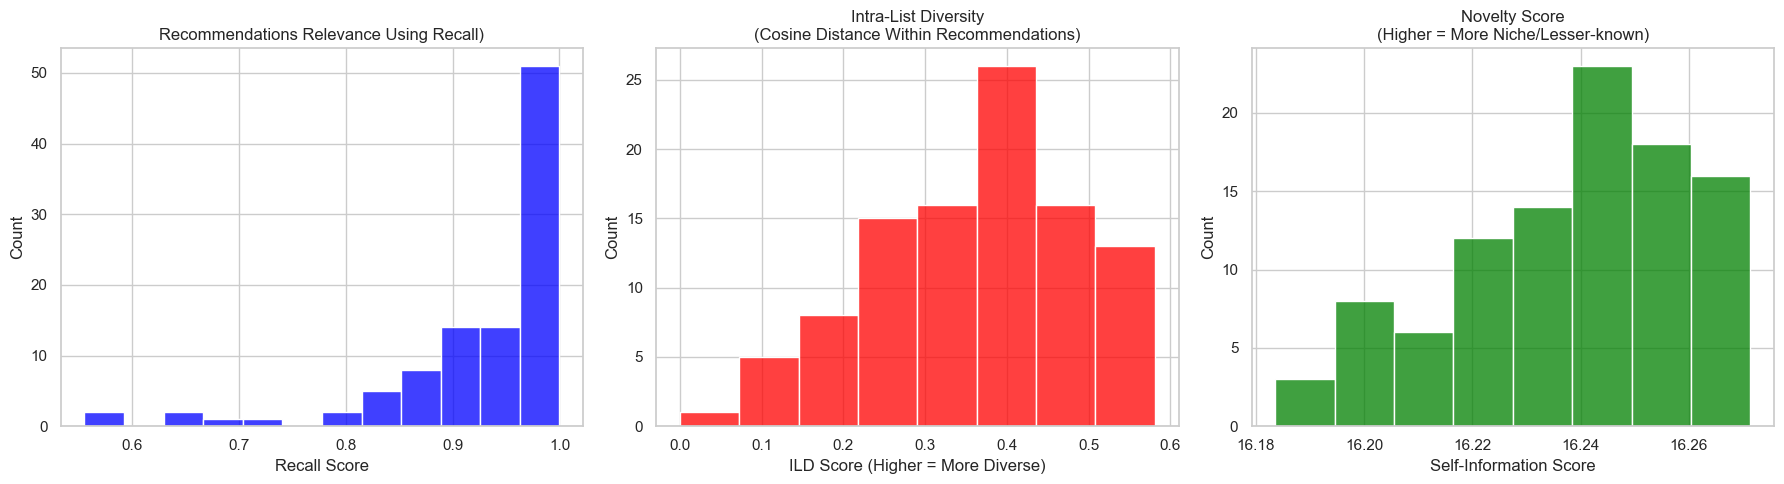

In [153]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recall
sns.histplot(df_metrics['Recall'], kde = False, ax = axes[0], color = 'blue')
axes[0].set_title('Recommendations Relevance Using Recall)')
axes[0].set_xlabel('Recall Score')
axes[0].set_ylabel('Count')

# Plot 2: Intra-List Diversity.
sns.histplot(df_metrics['Intra-List Diversity'], kde = False, ax = axes[1], color='red')
axes[1].set_title('Intra-List Diversity\n(Cosine Distance Within Recommendations)')
axes[1].set_xlabel('ILD Score (Higher = More Diverse)')
axes[1].set_ylabel('Count')

# Plot 3: Novelty Distributions
sns.histplot(df_metrics['Novelty (Self-Info)'], kde = False, ax = axes[2], color = 'green')
axes[2].set_title('Novelty Score\n(Higher = More Niche/Lesser-known)')
axes[2].set_xlabel('Self-Information Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## iii.3. Interpreting Evaluation Metrics

# iv. Conclusions & Future Work 